<a href="https://colab.research.google.com/github/lca-7/wine_quality_classification/blob/main/notebooks/Tech_WineQuality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Classificação de Qualidade de Vinhos

## 1. Compreensão do Problema
O objetivo deste projeto é prever a qualidade do vinho (especificamente vinhos tintos da variante 'Vinho Verde' português) com base em testes físico-químicos.

**Definição do Target:**
Transformaremos a escala original de qualidade (3-8) em uma classificação binária:
- **0 (Abaixo da Média/Ruim):** Score < 6
- **1 (Bom):** Score >= 6



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier

# 1. Carregamento
df = pd.read_csv('/content/WineQT.csv', sep=';')

# 2. Limpeza Robusta (Tratando o formato específico de 'density' e 'quality')
def fix_numeric(val):
    if isinstance(val, str):
        val = val.replace(',', '.')
        if val.count('.') > 1:
            parts = val.split('.')
            val = parts[0] + '.' + ''.join(parts[1:])
    return val

df['density'] = df['density'].apply(fix_numeric).astype(float)
df['quality_raw'] = df['quality'].apply(fix_numeric).astype(float)

# 3. Definição do Target
df['target'] = (df['quality_raw'] >= 6).astype(int)

# 4. Remoção de colunas desnecessárias para o modelo
df = df.drop(columns=['Id', 'quality', 'quality_raw'], errors='ignore')

display(df.head())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,target
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.311111,1.747595,4.60000,7.10000,7.90000,9.100000,15.900
volatile acidity,1143.0,0.531339,0.179633,0.12000,0.39250,0.52000,0.640000,1.580
citric acid,1143.0,0.268364,0.196686,0.00000,0.09000,0.25000,0.420000,1.000
residual sugar,1143.0,2.532152,1.355917,0.90000,1.90000,2.20000,2.600000,15.500
chlorides,1143.0,0.086933,0.047267,0.01200,0.07000,0.07900,0.090000,0.611
free sulfur dioxide,1143.0,15.615486,10.250486,1.00000,7.00000,13.00000,21.000000,68.000
total sulfur dioxide,1143.0,45.914698,32.782130,6.00000,21.00000,37.00000,61.000000,289.000
density,1143.0,2.258444,9.793424,0.99007,0.99557,0.99668,0.997845,100.369
pH,1143.0,3.311015,0.156664,2.74000,3.20500,3.31000,3.400000,4.010
sulphates,1143.0,0.657708,0.170399,0.33000,0.55000,0.62000,0.730000,2.000


Count of quality values >= 6 (Good): 621
Count of quality values <= 5 (Bad/Average): 522


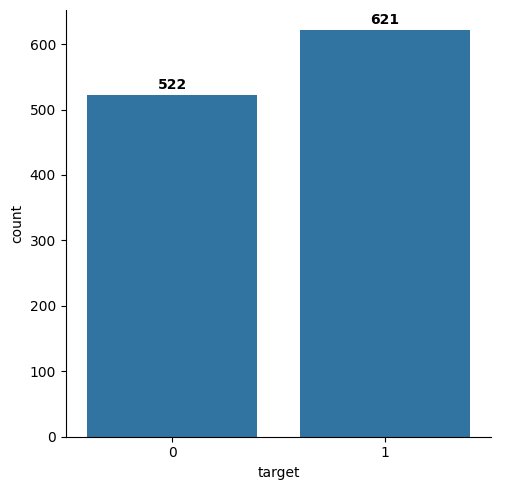

In [ ]:
quality_good = df['target'][df['target'] >= 1].count()
quality_bad_average = df['target'][df['target'] < 1].count()

print(f'Count of quality values >= 6 (Good): {quality_good}')
print(f'Count of quality values <= 5 (Bad/Average): {quality_bad_average}')

g = sns.catplot(data=df, x='target', kind='count')

for ax in g.axes.flat:
    for p in ax.patches:
        ax.text(p.get_x() + p.get_width() / 2., p.get_height() + 5,
                '{:1.0f}'.format(p.get_height()),
                ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Análise Exploratória de Dados (EDA)
Nesta etapa, investigamos padrões e correlações para entender o que diferencia um vinho 'bom'.

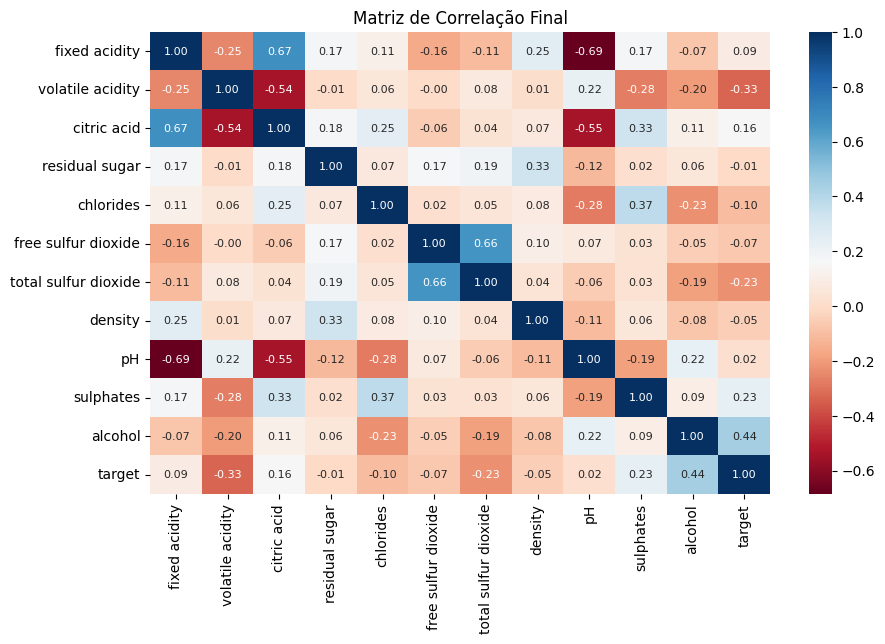

In [ ]:
plt.figure(figsize=(10, 6))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='RdBu', fmt='.2f', annot_kws={'size': 8})
plt.title('Matriz de Correlação Final')
plt.show()

## 3. Pré-processamento e Modelagem
Preparação dos dados e treinamento de modelos (Logistic Regression vs Random Forest vs KNN).

In [ ]:
# Separação de Features e Target
X = df.drop('target', axis=1)
y = df['target']

# Split Estratificado
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Padronização (Essencial para KNN e Regressão Logística)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Inicialização dos Modelos
rf = RandomForestClassifier(n_estimators=100, random_state=42)
log_reg = LogisticRegression(random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

# Treinamento
rf.fit(X_train, y_train)
log_reg.fit(X_train_scaled, y_train)
knn.fit(X_train_scaled, y_train)

print("Modelos treinados com sucesso: Random Forest, Regressão Logística e KNN.")

Modelos treinados com sucesso: Random Forest, Regressão Logística e KNN.


## 4. Avaliação e Interpretação
Comparação de performance e identificação das variáveis críticas.

Acurácia Random Forest: 79.91%
Acurácia Log. Regression: 77.29%
Acurácia KNN: 70.74%


/tmp/ipykernel_3327/2770924367.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=modelos, y=acuracias, palette='viridis')


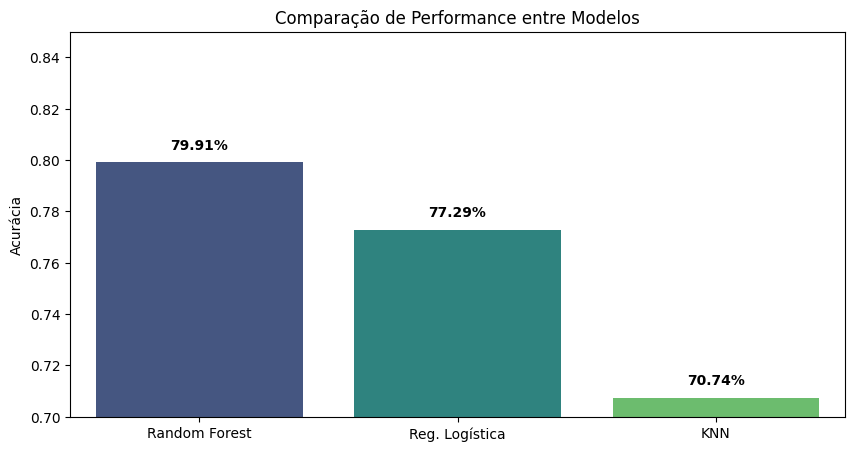

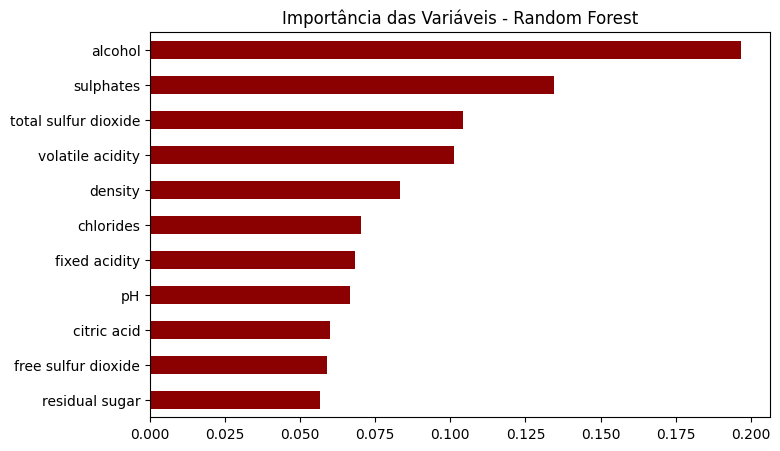

In [ ]:
# Avaliação dos Modelos
y_pred_rf = rf.predict(X_test)
y_pred_log = log_reg.predict(X_test_scaled)
y_pred_knn = knn.predict(X_test_scaled)

acc_rf = accuracy_score(y_test, y_pred_rf)
acc_log = accuracy_score(y_test, y_pred_log)
acc_knn = accuracy_score(y_test, y_pred_knn)

print(f"Acurácia Random Forest: {acc_rf:.2%}")
print(f"Acurácia Log. Regression: {acc_log:.2%}")
print(f"Acurácia KNN: {acc_knn:.2%}")

# Comparação Visual
modelos = ['Random Forest', 'Reg. Logística', 'KNN']
acuracias = [acc_rf, acc_log, acc_knn]

plt.figure(figsize=(10, 5))
sns.barplot(x=modelos, y=acuracias, palette='viridis')
plt.title('Comparação de Performance entre Modelos')
plt.ylabel('Acurácia')
plt.ylim(0.7, 0.85)
for i, val in enumerate(acuracias):
    plt.text(i, val + 0.005, f'{val:.2%}', ha='center', fontweight='bold')
plt.show()

# Visualização de Importância (Random Forest)
feat_importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
plt.figure(figsize=(8, 5))
feat_importances.plot(kind='barh', color='darkred')
plt.title('Importância das Variáveis - Random Forest')
plt.show()

6. Interpretacão dos Resultados e Implicaçõees para Produçãoo

Com base no melhor modelo (Random Forest), identificamos os principais drivers de qualidade:

    Alcool: O fator mais decisivo. Na produção, garantir a maturação ideal da uva e o controle da fermentação é vital.
    Sulfatos: Influenciam na conservaçãoo. O controle preciso da adição de SO2 é um diferencial técnico.
    Acidez Volátil: Deve ser minimizada. Indica a presença de bactérias acticas; o controle sanitário no processo é fundamental.


In [ ]:
print("=== Comparação Final ===")
print(f"Melhor Modelo: Random Forest")
print(f"Acurácia Alcançada: {acc_rf:.2%}")
print("------------------------------------")

=== Comparação Final ===
Melhor Modelo: Random Forest
Acurácia Alcançada: 79.91%
------------------------------------


## 7. Refinamento: Tratamento de Outliers (IQR)
Garantindo que ruídos experimentais não enviesem o modelo. Utilizaremos o Interquartile Range (IQR) para filtrar valores extremos nas variáveis mais críticas.

In [ ]:
# Identificando e removendo outliers nas colunas de maior impacto
cols_to_filter = ['alcohol', 'volatile acidity', 'sulphates']
df_final = df

Q1 = df_final[cols_to_filter].quantile(0.25)
Q3 = df_final[cols_to_filter].quantile(0.75)
IQR = Q3 - Q1

# Aplicando o filtro
df_filtered = df_final[~((df_final[cols_to_filter] < (Q1 - 1.5 * IQR)) | (df_final[cols_to_filter] > (Q3 + 1.5 * IQR))).any(axis=1)]


print(f"Registros originais: {len(df_final)}")
print(f"Registros após remoção de outliers: {len(df_filtered)}")
print(f"Volume de dados removido: {len(df_final) - len(df_filtered)} linhas")

Registros originais: 1143
Registros após remoção de outliers: 1075
Volume de dados removido: 68 linhas


## 8. Modelo de Produção Final
Retreinamos o melhor modelo (Random Forest) com os dados limpos para obter as métricas finais de performance.

In [ ]:
# Dividindo dados filtrados
X_f = df_no_outliers.drop('target', axis=1)
y_f = df_no_outliers['target']

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_f, y_f, test_size=0.2, random_state=42, stratify=y_f)

# Treino final
rf_final = RandomForestClassifier(n_estimators=150, random_state=42)
rf_final.fit(X_train_f, y_train_f)

# Avaliação Final
final_acc = rf_final.score(X_test_f, y_test_f)
print(f"Acurácia Pós-Tratamento de Outliers: {final_acc:.2%}")
print("\nRelatório de Producão:")
print(classification_report(y_test_f, rf_final.predict(X_test_f)))

Acurácia Pós-Tratamento de Outliers: 79.07%

Relatório de Producão:
              precision    recall  f1-score   support

           0       0.80      0.71      0.75        97
           1       0.78      0.86      0.82       118

    accuracy                           0.79       215
   macro avg       0.79      0.78      0.79       215
weighted avg       0.79      0.79      0.79       215



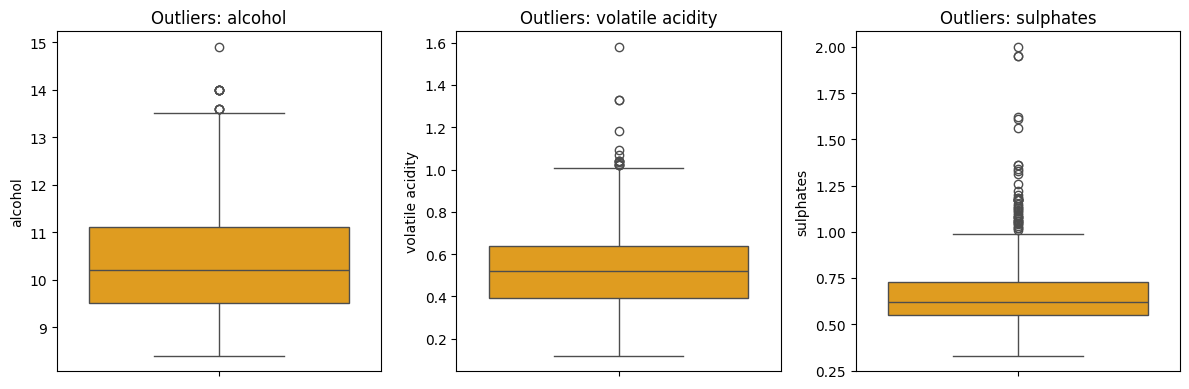

Registros antes: 1143
Registros após remoção de outliers: 1075
Redução de 5.9% nos dados.


In [ ]:
# Identificando Outliers nas variáveis principais (Alcohol e Volatile Acidity)
cols_to_check = ['alcohol', 'volatile acidity', 'sulphates']

# Visualização antes do tratamento
plt.figure(figsize=(12, 4))
for i, col in enumerate(cols_to_check):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df_final[col], color='orange')
    plt.title(f'Outliers: {col}')
plt.tight_layout()
plt.show()

# Aplicação do Filtro IQR
Q1 = df_final[cols_to_check].quantile(0.25)
Q3 = df_final[cols_to_check].quantile(0.75)
IQR = Q3 - Q1

# Definindo limites
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filtrando o DataFrame
df_no_outliers = df_final[~((df_final[cols_to_check] < lower_bound) | (df_final[cols_to_check] > upper_bound)).any(axis=1)]

print(f"Registros antes: {len(df_final)}")
print(f"Registros após remoção de outliers: {len(df_no_outliers)}")
print(f"Redução de {((len(df_final) - len(df_no_outliers))/len(df_final)):.1%} nos dados.")